# Confronto tra Selection Sort e Quick Sort

**Laboratorio di Algoritmi e Strutture Dati — A.A. 2025/2026**

In questo notebook vengono implementati e confrontati gli algoritmi di ordinamento **Selection Sort** e **Quick Sort**.

## Obiettivo dell'esercizio

L'obiettivo dell'esercizio è confrontare **Selection Sort** e **Quick Sort** ed osservarne il comportamento al variare delle caratteristiche e della dimensione dell'input.

Il notebook contiene l'intero svolgimento dell'esercizio: implementazione degli algoritmi, verifica della correttezza, generazione dei dati di test, esecuzione degli esperimenti, presentazione dei risultati e loro analisi.

In accordo con la traccia:

- i dati di test vengono generati direttamente nel notebook;
- esecuzioni diverse del notebook generano dati diversi;
- i test vengono eseguiti nel notebook e producono direttamente i risultati;
- la documentazione del codice e la descrizione degli esperimenti sono riportate nelle celle Markdown.

Gli algoritmi di ordinamento sono implementati direttamente, senza utilizzare funzioni o librerie di ordinamento come loro sostituzione.

Il confronto sperimentale considera quattro tipologie di input:

1. valori distinti in ordine casuale;
2. valori già ordinati;
3. valori ordinati in senso inverso;
4. valori casuali con molti duplicati.

Le principali metriche considerate sono il **tempo di esecuzione**, il **numero di confronti** e il **numero di scambi**. Per il calcolo del numero di confronti e di scambi sono create due versioni strumentate a tale obiettivo dei due algoritmi, in modo tale che il conteggio non influisca sui tempi di esecuzione. Inoltre, il conteggio di confronti e scambi consente un'analisi indipendente dalle prestazioni dell'ambiente di esecuzione.

### Definizione delle operazioni conteggiate

Un **confronto** è un confronto tra valori dell'array effettuato per determinarne l'ordine.

Non vengono quindi conteggiati confronti relativi a indici, condizioni dei cicli o condizioni che controllano la ricorsione.

In particolare:

- in Selection Sort viene contato ogni confronto tra un elemento della parte non ordinata e il minimo corrente;
- in Quick Sort viene contato ogni confronto tra un elemento e il pivot effettuato durante la partizione.

Uno **scambio** corrisponde a ogni esecuzione dell'operazione che scambia due posizioni dell'array.

Vengono conteggiati anche gli **auto-scambi**, cioè i casi nei quali le due posizioni coincidono. Questa convenzione permette di contare direttamente le operazioni di scambio previste dall'algoritmo, senza introdurre condizioni aggiuntive nella versione strumentata.

Le versioni strumentate mantengono quindi lo stesso comportamento algoritmico delle versioni normali e aggiungono solamente l'aggiornamento dei contatori.

## Teoria e aspettative sperimentali

### Selection Sort

Selection Sort mantiene una parte iniziale dell'array già ordinata. A ogni iterazione individua il valore minimo nella parte ancora non ordinata e lo scambia con l'elemento che occupa la prima posizione di tale parte.

L'algoritmo opera **in-place** e, per individuare il minimo, deve esaminare progressivamente gli elementi della parte non ancora ordinata. Il numero di confronti non dipende quindi dall'ordinamento iniziale dei dati e il tempo di esecuzione è atteso di ordine quadratico, $\Theta(n^2)$, sia su input favorevoli sia su input sfavorevoli.

### Quick Sort

Quick Sort utilizza l'approccio **divide et impera**. L'array viene suddiviso rispetto a un pivot e i due sottoarray ottenuti vengono successivamente ordinati mediante chiamate ricorsive.

Nella versione utilizzata in questo notebook l'algoritmo è **ricorsivo e in-place**, utilizza come pivot l'ultimo elemento del sottoarray e adotta la **partizione come vista a lezione**, nella quale gli elementi minori o uguali al pivot vengono collocati nella parte sinistra.

Come visto a lezione, le prestazioni di Quick Sort dipendono dalla qualità delle partizioni ottenute. Quando le partizioni sono bilanciate il comportamento è dell'ordine di $\Theta(n \log n)$; quando invece risultano fortemente sbilanciate si può raggiungere il caso peggiore $\Theta(n^2)$. Con la scelta dell'ultimo elemento come pivot, un input già ordinato costituisce un caso particolarmente sfavorevole.

### Obiettivo del confronto

Gli esperimenti sservono a verificare quanto queste differenze teoriche siano osservabili nell'esecuzione reale. In particolare verrà studiato l'effetto della dimensione dell'input, dell'ordinamento iniziale e della presenza di valori duplicati sui tempi di esecuzione e sul numero di operazioni effettuate dai due algoritmi.

## Import e configurazione iniziale

In [1]:
# Le importazioni necessarie per generazione dei dati, benchmark e grafici
import random
import os
import platform
import statistics
import sys
import time
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

## Implementazione di Selection Sort

Viene inizialmente implementata la versione normale di **Selection Sort**, che sarà successivamente utilizzata per il benchmark temporale.

L'implementazione segue direttamente l'algoritmo visto nel corso: a ogni iterazione viene cercato il valore minimo nella parte dell'array non ancora ordinata e tale valore viene scambiato con quello nella posizione corrente.

L'algoritmo opera **in-place**, quindi modifica direttamente l'array ricevuto in ingresso senza creare un secondo array ordinato.

In [2]:
def selection_sort(A):
    """
    Ordina l'array A in ordine non decrescente utilizzando Selection Sort.

    L'algoritmo opera in-place: l'array ricevuto viene modificato
    direttamente e non viene restituito un nuovo array.

    Parametri:
    - A : list, Array di valori confrontabili da ordinare.

    Returns:
    - None, L'ordinamento viene effettuato direttamente su A.
    """

    n = len(A)

    # Dopo ogni iterazione, A[0:i+1] contiene gli elementi più piccoli dell'array nelle loro posizioni definitive
    for i in range(n - 1):
        min_index = i

        # Cerca il minimo nella parte dell'array non ancora ordinata
        for j in range(i + 1, n):
            if A[j] < A[min_index]:
                min_index = j

        # Porta il minimo trovato nella posizione corrente (anche quando min_index == i)
        A[i], A[min_index] = A[min_index], A[i]

### Input, output e funzionamento

La funzione `selection_sort(A)` riceve in ingresso una lista `A` contenente valori confrontabili e la ordina in ordine non decrescente. Operando **in-place**, il valore di ritorno è `None`

Sia `n` la lunghezza dell'array. L'algoritmo considera una posizione `i` alla volta, dalla prima fino alla penultima. Inizialmente assume che l'elemento in posizione `i` sia il minimo della parte dell'array ancora da ordinare. Attraversando le posizioni successive con l'indice `j`, aggiorna `min_index` ogni volta che incontra un valore più piccolo.

Terminata la ricerca, l'elemento minimo individuato viene scambiato con quello nella posizione `i`. Dopo lo scambio, l'elemento in posizione `i` si trova nella sua posizione definitiva.

Il procedimento viene eseguito soltanto per le prime `n-1` posizioni: quando queste sono state sistemate, anche l'ultimo elemento è necessariamente nella posizione corretta.

La ricerca del minimo viene effettuata per ogni posizione indipendentemente dall'ordinamento iniziale dell'input. Il numero di confronti tra valori è quindi

\[
(n-1) + (n-2) + \dots + 1
= \frac{n(n-1)}{2},
\]

e il tempo di esecuzione è $\Theta(n^2)$ sia nel caso migliore sia nel caso peggiore.

## Implementazione strumentata del Selection Sort

Viene implementata una seconda versione di Selection Sort utilizzata esclusivamente per il conteggio del numero di **confronti** e di **scambi** effettuati.

L'implementazione riprende la versione normale dell'algoritmo e aggiunge solamente due contatori. L'algoritmo continua quindi a operare **in-place** e mantiene lo stesso comportamento della versione normale.

Come già specificato:

- un **confronto** corrisponde a ogni confronto tra due valori dell'array effettuato per determinarne l'ordine;
- uno **scambio** corrisponde a ogni esecuzione dell'operazione che scambia due posizioni dell'array.

Vengono conteggiati anche gli **auto-scambi**, cioè i casi in cui i due indici dello scambio coincidono. Non vengono introdotte condizioni aggiuntive per evitarli, in modo da mantenere la versione strumentata aderente alla versione normale dell'algoritmo. 

In [3]:
def selection_sort_strumentato(A) -> tuple[int, int]:
    """
    Ordina l'array A in ordine non decrescente utilizzando Selection Sort
    e conta il numero di scambi e confronti effettuati

    L'algoritmo opera in-place: l'array ricevuto viene modificato
    direttamente e non viene restituito un nuovo array.

    Parametri:
    - A : list, Array di valori confrontabili da ordinare.

    Returns:
    - tuple[int, int]: numero di confronti, numero di scambi.

    """
    n = len(A)
    
    # Inizializzo i counters
    c_confronti = 0
    c_scambi = 0
    
    # Dopo ogni iterazione, A[0:i+1] contiene gli elementi più piccoli dell'array nelle loro posizioni definitive
    for i in range(n - 1):
        min_index = i

        # Cerca il minimo nella parte dell'array non ancora ordinata
        for j in range(i + 1, n):

            # Conteggio confronti
            c_confronti += 1
            
            if A[j] < A[min_index]:
                min_index = j

        # Porta il minimo trovato nella posizione corrente (anche quando min_index == i)
        # Lo scambio viene eseguito anche quando min_index == i.
        A[i], A[min_index] = A[min_index], A[i]
        c_scambi += 1

    return c_confronti, c_scambi

## Implementazione del QuickSort

Viene inizialmente implementata la versione normale del **QuickSort**, che sarà successivamente utilizzata per il benchmark temporale.

L'implementazione segue l'algoritmo visto a lezione: è **ricorsiva**, opera **in-place** e utilizza come pivot l'ultimo elemento del sottoarray considerato. 

La suddivisione dell'array viene effettuata mediante la **partizione come vista a lezione**, utilizzando il confronto `<=` tra gli elementi esaminati e il pivot.

Non viene effettuata alcuna randomizzazione del pivot o dell'input all'interno dell'algoritmo, in modo da mantenere la variante oggetto del confronto

In [4]:
def partition(A, p, r) -> int:
    """
    Partiziona il sottoarray A[p:r+1] utilizzando A[r] come pivot.

    Al termine della procedura, il pivot si trova nella sua posizione
    definitiva. Gli elementi alla sua sinistra sono minori o uguali
    al pivot, mentre quelli alla sua destra sono maggiori del pivot.

    Parametri:
    - A (list): Array da partizionare
    - p (int): Indice i, indice iniziale del sottoarray
    - r (int): Indice finale del sottoarray. A[r] viene utilizzato come pivot.

    Returns:
    - int: Indice della posizione finale del pivot.
    """

    pivot = A[r]
    i = p - 1

    # Esamina tutti gli elementi del sottoarray tranne il pivot.
    for j in range(p, r):
        if A[j] <= pivot:
            i += 1
            A[i], A[j] = A[j], A[i]

    # Posiziona il pivot tra le due parti ottenute.
    A[i + 1], A[r] = A[r], A[i + 1]

    return i + 1


def _quick_sort(A, p, r) -> None:
    """
    Ordina ricorsivamente il sottoarray A[p:r+1] utilizzando Quick Sort.

    Parametri:
    - A (list): Array da partizionare
    - p (int): Indice i, indice iniziale del sottoarray
    - r (int): Indice finale del sottoarray. A[r] viene utilizzato come pivot.

    Returns: 
    - None: L'ordinamento è effettuato direttamente su A
    """

    if p < r:
        q = partition(A, p, r)

        _quick_sort(A, p, q - 1)
        _quick_sort(A, q + 1, r)


def quick_sort(A) -> None:
    """
    Ordina l'array A in ordine non decrescente utilizzando Quick Sort.

    L'algoritmo opera in-place: l'array ricevuto viene modificato
    direttamente e non viene restituito un nuovo array.

    La funzione svolge il ruolo di facciata.

    Parametri:
    A (list): Array di valori confrontabili da ordinare.

    Returns: 
    - None: L'ordinamento è effettuato direttamente su A
    """

    _quick_sort(A, 0, len(A) - 1)

### Pivot, partizione e ricorsione

La funzione `quick_sort(A)` avvia l'ordinamento dell'intero array, mentre `_quick_sort(A, p, r)` gestisce ricorsivamente il sottoarray compreso tra gli indici `p` e `r`.

#### Pivot

Per ogni chiamata viene utilizzato come **pivot** l'ultimo elemento del sottoarray corrente, cioè `A[r]`.

La scelta del pivot determina come il sottoarray viene suddiviso e può quindi influenzare significativamente il comportamento di Quick Sort. In questa implementazione la scelta rimane sempre deterministica e non viene effettuata alcuna randomizzazione.

#### Partizione

La funzione `partition(A, p, r)` riorganizza il sottoarray rispetto al pivot.

L'indice `i` individua inizialmente una posizione precedente all'inizio del sottoarray. L'indice `j` attraversa invece gli elementi da `p` a `r - 1`.

Quando viene incontrato un elemento `A[j]` minore o uguale al pivot, `i` viene incrementato e gli elementi nelle posizioni `i` e `j` vengono scambiati.

Terminata la scansione, il pivot viene scambiato con l'elemento in posizione `i + 1`. In questo modo il pivot raggiunge la propria posizione definitiva `q`.

Al termine della partizione:

- gli elementi in `A[p:q]` sono minori o uguali al pivot;
- `A[q]` è il pivot;
- gli elementi in `A[q+1:r+1]` sono maggiori del pivot.

La funzione restituisce quindi l'indice `q`.

#### Ricorsione

Dopo la partizione, il pivot non deve più essere considerato perché si trova già nella posizione corretta.

Quick Sort viene quindi applicato ricorsivamente ai due sottoarray:

- `A[p:q]`, alla sinistra del pivot;
- `A[q+1:r+1]`, alla destra del pivot.

La ricorsione prosegue soltanto quando `p < r`. Un sottoarray vuoto o composto da un solo elemento è infatti già ordinato e costituisce il caso base della procedura.

L'algoritmo opera interamente **in-place**: la partizione e le chiamate ricorsive modificano direttamente l'array originale senza costruire sottoarray separati.

## Implementazione strumentata del Quick Sort

Viene implementata una seconda versione di Quick Sort destinata al conteggio di **confronti** e **scambi**. La struttura dell'algoritmo rimane invariata rispetto alla versione normale.

Durante ogni partizione vengono conteggiati i confronti tra gli elementi del sottoarray e il pivot e tutti gli scambi eseguiti, compresi gli auto-scambi.

Poiché Quick Sort utilizza il paradigma divide et impera, ogni chiamata ricorsiva restituisce il numero di confronti e scambi effettuati nel proprio sottoarray. I valori complessivi vengono ottenuti sommando le operazioni eseguite nella partizione corrente con quelle delle due chiamate ricorsive sui sottoarray sinistro e destro.

In questo modo la strumentazione non modifica la logica dell'algoritmo, ma aggiunge solamente la raccolta delle metriche.

In [5]:
def partition_strumentato(A, p, r) -> tuple[int, int, int]:
    """
    Partiziona il sottoarray A[p:r+1] utilizzando A[r] come pivot
    e conta confronti e scambi effettuati.

    Parametri:
    - A (list): array da partizionare;
    - p (int): indice iniziale del sottoarray;
    - r (int): indice finale del sottoarray. A[r] è il pivot.

    Returns:
    - tuple[int, int, int]:
        - posizione finale del pivot;
        - numero di confronti effettuati nella partizione;
        - numero di scambi effettuati nella partizione.
    """

    pivot = A[r]
    i = p - 1

    c_confronti = 0
    c_scambi = 0

    # Esamina tutti gli elementi del sottoarray tranne il pivot.
    for j in range(p, r):
        # Viene contato ogni confronto tra A[j] e il pivot.
        c_confronti += 1

        if A[j] <= pivot:
            i += 1

            # Lo scambio viene contato anche quando i == j.
            A[i], A[j] = A[j], A[i]
            c_scambi += 1

    # Posiziona il pivot nella sua posizione definitiva.
    # Anche questo scambio viene sempre contato.
    A[i + 1], A[r] = A[r], A[i + 1]
    c_scambi += 1

    return i + 1, c_confronti, c_scambi


def _quick_sort_strumentato(A, p, r) -> tuple[int, int]:
    """
    Ordina ricorsivamente il sottoarray A[p:r+1] utilizzando Quick Sort
    e restituisce il numero totale di confronti e scambi effettuati.

    Parametri:
    - A (list): array da ordinare;
    - p (int): indice iniziale del sottoarray;
    - r (int): indice finale del sottoarray.

    Returns:
    - tuple[int, int]:
        - numero totale di confronti;
        - numero totale di scambi.
    """

    # Caso base: sottoarray vuoto o formato da un solo elemento.
    if p >= r:
        return 0, 0

    # Partizione del sottoarray corrente.
    q, confronti_partizione, scambi_partizione = partition_strumentato(
        A, p, r
    )

    # Ordinamento ricorsivo della parte sinistra.
    confronti_sx, scambi_sx = _quick_sort_strumentato(
        A, p, q - 1
    )

    # Ordinamento ricorsivo della parte destra.
    confronti_dx, scambi_dx = _quick_sort_strumentato(
        A, q + 1, r
    )

    # Il costo della chiamata corrente è dato dalla somma
    # della partizione e delle due chiamate ricorsive.
    c_confronti = (
        confronti_partizione
        + confronti_sx
        + confronti_dx
    )

    c_scambi = (
        scambi_partizione
        + scambi_sx
        + scambi_dx
    )

    return c_confronti, c_scambi


def quick_sort_strumentato(A) -> tuple[int, int]:
    """
    Ordina l'array A in ordine non decrescente utilizzando Quick Sort
    e conta confronti e scambi.

    L'algoritmo opera in-place: A viene modificato direttamente.

    Parametri:
    - A (list): array di valori confrontabili da ordinare.

    Returns:
    - tuple[int, int]:
        - numero totale di confronti;
        - numero totale di scambi.
    """

    return _quick_sort_strumentato(A, 0, len(A) - 1)

## Verifica di correttezza

Prima di utilizzare gli algoritmi negli esperimenti viene verificata la correttezza delle implementazioni mediante alcuni test deterministici.

Per ogni caso di test, il risultato prodotto da Selection Sort e Quick Sort viene confrontato con quello ottenuto tramite `sorted()`, utilizzato esclusivamente come ordinamento di riferimento e non come implementazione degli algoritmi oggetto dell'esercizio.

Vengono considerati pochi casi rappresentativi:

- array vuoto;
- array contenente un solo elemento;
- array già ordinato;
- array ordinato in senso inverso;
- array contenente valori duplicati;
- array con valori distinti in ordine non regolare.

La verifica viene effettuata sia sulle versioni normali sia sulle versioni strumentate, controllando che tutte producano lo stesso ordinamento corretto.

In [6]:
# Casi deterministici utilizzati per verificare la correttezza.
casi_test = {
    "vuoto": [],
    "un elemento": [7],
    "già ordinato": [1, 2, 3, 4, 5],
    "ordine inverso": [5, 4, 3, 2, 1],
    "con duplicati": [4, 2, 4, 1, 2, 3],
    "ordine non regolare": [8, 3, 6, 1, 7, 2, 5, 4]
}


def verifica_ordinamento(nome, algoritmo):
    """
    Verifica che un algoritmo di ordinamento produca il risultato atteso
    su tutti i casi deterministici definiti sopra.

    Parametri:
    - nome (str): nome dell'algoritmo mostrato nell'output;
    - algoritmo (callable): funzione di ordinamento da verificare.

    Returns:
    - bool: True se tutti i test vengono superati, False altrimenti.
    """

    tutti_superati = True

    for nome_caso, dati in casi_test.items():
        # Ordinamento di riferimento.
        atteso = sorted(dati)

        # Gli algoritmi lavorano in-place, quindi viene usata una copia.
        ottenuto = dati.copy()

        # L'eventuale valore restituito dalla versione strumentata
        # non è rilevante per questo test di correttezza.
        algoritmo(ottenuto)

        corretto = ottenuto == atteso

        print(
            f"{nome} - {nome_caso}: "
            f"{'OK' if corretto else 'ERRORE'}"
        )

        if not corretto:
            tutti_superati = False
            print("  Atteso: ", atteso)
            print("  Ottenuto:", ottenuto)

    return tutti_superati


esiti = [
    verifica_ordinamento("Selection Sort", selection_sort),
    verifica_ordinamento(
        "Selection Sort strumentato",
        selection_sort_strumentato
    ),
    verifica_ordinamento("Quick Sort", quick_sort),
    verifica_ordinamento(
        "Quick Sort strumentato",
        quick_sort_strumentato
    )
]

print()
print("Tutti i test superati:", all(esiti))

Selection Sort - vuoto: OK
Selection Sort - un elemento: OK
Selection Sort - già ordinato: OK
Selection Sort - ordine inverso: OK
Selection Sort - con duplicati: OK
Selection Sort - ordine non regolare: OK
Selection Sort strumentato - vuoto: OK
Selection Sort strumentato - un elemento: OK
Selection Sort strumentato - già ordinato: OK
Selection Sort strumentato - ordine inverso: OK
Selection Sort strumentato - con duplicati: OK
Selection Sort strumentato - ordine non regolare: OK
Quick Sort - vuoto: OK
Quick Sort - un elemento: OK
Quick Sort - già ordinato: OK
Quick Sort - ordine inverso: OK
Quick Sort - con duplicati: OK
Quick Sort - ordine non regolare: OK
Quick Sort strumentato - vuoto: OK
Quick Sort strumentato - un elemento: OK
Quick Sort strumentato - già ordinato: OK
Quick Sort strumentato - ordine inverso: OK
Quick Sort strumentato - con duplicati: OK
Quick Sort strumentato - ordine non regolare: OK

Tutti i test superati: True


## Generazione dei dati sperimentali

I dati sperimentali vengono generati direttamente all'interno del notebook.

Ogni esecuzione utilizza un **seed casuale registrato**. La funzione `generate_seed()` genera un nuovo valore di seed e, a partire da esso, inizializza un oggetto `Random` (`rng`) utilizzato successivamente per la generazione dei dati.

Questa scelta consente di soddisfare due esigenze:

- a ogni nuova esecuzione del notebook viene generato un nuovo seed e quindi vengono normalmente prodotti dati differenti, come richiesto dalla traccia;
- il seed utilizzato viene conservato e mostrato a schermo, rendendo possibile riprodurre una specifica esecuzione in caso sia necessario analizzare risultati o anomalie.

Utilizzando nuovamente lo stesso seed è infatti possibile ricreare la stessa sequenza pseudocasuale di dati.

In [7]:
def generate_seed() -> tuple[int, random.Random]:
    """
    Genera il seed utilizzato per la generazione dei dati sperimentali
    e inizializza un generatore pseudocasuale dedicato.

    Il seed viene mostrato a schermo e restituito insieme all'oggetto
    Random, in modo da poter riprodurre successivamente la stessa
    sequenza di dati.

    Returns:
    - tuple[int, random.Random]:
        - seed utilizzato per l'esecuzione;
        - generatore pseudocasuale inizializzato con tale seed.
    """

    # Genera un seed casuale a 64 bit utilizzando la sorgente
    # di casualità fornita dal sistema operativo.
    seed = random.SystemRandom().getrandbits(64)

    print(f"Seed utilizzato per la generazione dei dati: {seed}")

    # Generatore pseudocasuale dedicato all'esperimento.
    rng = random.Random(seed)

    return seed, rng

In [8]:
def generate_input(n, rng):
    """
    Genera i quattro tipi di input utilizzati negli esperimenti.

    I tre input con valori distinti contengono gli stessi elementi,
    disposti rispettivamente in ordine casuale, crescente e decrescente.

    L'input con duplicati contiene circa il 35% di occorrenze duplicate.

    Parametri:
    - n (int): dimensione delle liste da generare;
    - rng (random.Random): generatore pseudocasuale da utilizzare.

    Returns:
    - tuple[list, list, list, list]:
        - casuali_distinti: valori distinti in ordine casuale;
        - casuali_ordinati: stessi valori distinti in ordine crescente;
        - casuali_inversi: stessi valori distinti in ordine decrescente;
        - casuali_duplicati: valori casuali con circa il 35% di duplicati.
    """

    if n < 0:
        raise ValueError("La dimensione n deve essere non negativa.")

    if n == 0:
        return [], [], [], []

    # Scelgo un intervalllo sufficientemente ampio per avere valori distinti
    valori_distinti = rng.sample(range(10 * n), n)

    # Primo scenario: valori distinti in ordine casuale.
    casuali_distinti = valori_distinti.copy()

    # Secondo scenario: gli stessi valori in ordine crescente.
    casuali_ordinati = sorted(valori_distinti)

    # Terzo scenario: gli stessi valori in ordine decrescente.
    casuali_inversi = sorted(valori_distinti, reverse=True)

    # Quarto scenario: circa il 35% degli elementi è costituito da duplicati
    numero_unici = max(1, round(n * 0.65))
    numero_duplicati = n - numero_unici

    # Genera inizialmente valori distinti.
    valori_unici = rng.sample(range(10 * n), numero_unici)

    # Aggiunge occorrenze scelte tra i valori già presenti.
    casuali_duplicati = valori_unici.copy()

    for _ in range(numero_duplicati):
        casuali_duplicati.append(rng.choice(valori_unici))

    # Mescola la lista
    rng.shuffle(casuali_duplicati)

    return (
        casuali_distinti,
        casuali_ordinati,
        casuali_inversi,
        casuali_duplicati
    )

## Protocollo sperimentale

L'obiettivo dell'esperimento è confrontare **Selection Sort** e **Quick Sort** e osservarne il comportamento al variare della dimensione e delle caratteristiche dell'input.

I due algoritmi vengono valutati su quattro scenari:

- valori distinti generati casualmente;
- gli stessi tipi di valori distinti disposti in ordine crescente;
- gli stessi tipi di valori distinti disposti in ordine decrescente;
- valori casuali con presenza di duplicati, fissata a circa il 35% degli elementi.

Per ogni scenario vengono analizzate separatamente le due tipologie di misurazione:

- le implementazioni normali vengono utilizzate per misurare il **tempo di esecuzione** dell'ordinamento;
- le implementazioni strumentate vengono utilizzate per misurare il **numero di confronti** e di **scambi** effettuati.

La strumentazione non viene quindi inclusa nelle misurazioni temporali.

### Parametri sperimentali

Le dimensioni degli input considerate sono:

`50, 100, 200, 400, 800`.

La progressione per raddoppio permette di osservare con maggiore chiarezza come varia il costo degli algoritmi all'aumentare di `n`.

Ogni combinazione tra dimensione e scenario viene eseguita **30 volte**.

Per ogni ripetizione vengono generati nuovi dati attraverso il generatore pseudocasuale `rng`. All'interno della stessa ripetizione, Selection Sort e Quick Sort ricevono una copia dello stesso input iniziale, poiché entrambi gli algoritmi operano in-place.

Il seed da cui deriva `rng` viene generato e registrato prima della generazione degli input sperimentali.

### Misurazione dei tempi

Il tempo viene misurato tramite `time.perf_counter_ns()` e misura esclusivamente la chiamata alla funzione di ordinamento. 

L'ordine di esecuzione dei due algoritmi viene alternato tra le ripetizioni, in modo da non eseguire sistematicamente uno dei due sempre prima dell'altro. In questo modo si evita che un vantaggio o svantaggio derivante dalla posizione nell'ordine di esecuzione ricada sempre sullo stesso algoritmo.

I tempi grezzi vengono conservati in nanosecondi e successivamente rappresentati in **microsecondi**.

Per sintetizzare le 30 ripetizioni vengono utilizzati:

- mediana;
- intervallo interquartile (IQR).

La mediana viene utilizzata come valore principale perché è meno sensibile della media a eventuali misurazioni temporali anomale, mentre IQR è utilizzato come indicatore della variabilità.

### Limite di ricorsione

Poiché Quick Sort è implementato ricorsivamente e gli input ordinati possono produrre una profondità ricorsiva proporzionale a n, la dimensione massima viene verificata rispetto al limite di ricorsione dell'interprete. Viene mantenuto un piccolo margine di sicurezza per tenere conto delle chiamate già presenti nell'ambiente di esecuzione. Il limite di ricorsione non viene modificato.

In [9]:
# Parametri sperimentali definitivi
DIMENSIONI = [50, 100, 200, 400, 800]
RIPETIZIONI = 30

# Margine mantenuto rispetto al limite di ricorsione di Python.
MARGINE_RICORSIONE = 100

# Informazioni sull'ambiente di esecuzione
limite_ricorsione = sys.getrecursionlimit()
processore = platform.processor() or "non disponibile"

print("PARAMETRI SPERIMENTALI")
print(f"Dimensioni: {DIMENSIONI}")
print(f"Ripetizioni: {RIPETIZIONI}")

print("\nAMBIENTE DI ESECUZIONE")
print(f"Python: {platform.python_version()}")
print(f"Sistema operativo: {platform.system()} {platform.release()}")
print(f"Architettura: {platform.machine()}")
print(f"Processore: {processore}")
print(f"Processori logici: {os.cpu_count()}")
print(f"Limite di ricorsione Python: {limite_ricorsione}")


# Controllo preventivo per il Quick Sort ricorsivo.
if max(DIMENSIONI) > limite_ricorsione - MARGINE_RICORSIONE:
    raise RuntimeError("La dimensione massima scelta è troppo vicina al limite di ricorsione di Python.")


PARAMETRI SPERIMENTALI
Dimensioni: [50, 100, 200, 400, 800]
Ripetizioni: 30

AMBIENTE DI ESECUZIONE
Python: 3.14.3
Sistema operativo: Windows 11
Architettura: AMD64
Processore: Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
Processori logici: 16
Limite di ricorsione Python: 1000


## Benchmark temporale

Il benchmark temporale viene eseguito dalla funzione `run_benchmark_temporale(rng)`.

Per ogni dimensione prevista dal protocollo vengono create delle liste temporanee nelle quali raccogliere i tempi delle 30 ripetizioni. A ogni ripetizione `generate_input(n, rng)` produce i quattro scenari sperimentali.

Per ciascuno scenario, Selection Sort e Quick Sort ricevono due copie dello stesso input iniziale. La copia viene effettuata prima dell'avvio del timer, in modo che la misurazione comprenda esclusivamente l'esecuzione dell'algoritmo di ordinamento.

L'ordine dei due algoritmi viene alternato tra una ripetizione e la successiva. Nelle ripetizioni pari viene eseguito prima Selection Sort, mentre in quelle dispari viene eseguito prima Quick Sort.

I tempi vengono misurati tramite `time.perf_counter_ns()`.

Al termine delle 30 ripetizioni per una determinata dimensione, la funzione `aggrega_risultati()` calcola per ogni scenario:

- la **mediana** dei tempi;
- l'**intervallo interquartile (IQR)**.

I valori aggregati vengono inseriti in un dizionario indicizzato prima per scenario e poi per dimensione.

La funzione restituisce separatamente i risultati aggregati di Selection Sort e Quick Sort. I valori rimangono espressi in nanosecondi e saranno convertiti in microsecondi nelle successive celle dedicate alla presentazione dei risultati.

In [10]:
# Il seed viene generato e registrato prima della generazione degli input utilizzati nel benchmark
seed, rng = generate_seed()

def aggrega_risultati(tempi_grezzi, tempi_aggregati, dimensione):
    """
    Calcola mediana e IQR dei tempi raccolti per ogni scenario
    e aggiorna il dizionario dei risultati aggregati.

    I tempi ricevuti e i valori aggregati sono espressi in nanosecondi.

    Parametri:
    - tempi_grezzi (dict): dizionario che associa ogni scenario alla lista dei tempi misurati nelle diverse ripetizioni;
    - tempi_aggregati (dict): dizionario nel quale vengono memorizzati i risultati aggregati;
    - dimensione (int): dimensione degli input a cui si riferiscono le misure.

    Returns:
    - dict: dizionario aggiornato nella forma tempi_aggregati[scenario][dimensione] = (mediana, IQR).
    """

    for scenario, tempi in tempi_grezzi.items():

        # Valore centrale utilizzato come misura temporale principale
        mediana = statistics.median(tempi)

        # I quartili vengono calcolati esclusivamente per ricavare l'IQR
        q1, _, q3 = statistics.quantiles(
            tempi,
            n=4,
            method="inclusive"
        )

        iqr = q3 - q1

        tempi_aggregati[scenario][dimensione] = (mediana, iqr)

    return tempi_aggregati


def run_benchmark_temporale(rng):
    """
    Esegue il benchmark temporale di Selection Sort e Quick Sort
    secondo il protocollo sperimentale definito nel notebook.

    Per ogni dimensione vengono effettuate RIPETIZIONI prove sui quattro
    scenari di input. I due algoritmi ricevono copie dello stesso input
    iniziale e il loro ordine di esecuzione viene alternato tra le
    ripetizioni.

    Viene misurata esclusivamente la chiamata all'algoritmo di ordinamento. 

    Parametri:
    - rng (random.Random): generatore pseudocasuale utilizzato per creare gli input.

    Returns:
    - tuple[dict, dict]:
        - risultati aggregati di Selection Sort;
        - risultati aggregati di Quick Sort.

      Ogni dizionario ha struttura risultati[scenario][dimensione] = (mediana, IQR) con valori espressi in nanosecondi.
    """

    scenari = (
        "scenario casuali distinti",
        "scenario ordinati crescenti",
        "scenario ordinati decrescenti",
        "scenario casuali con duplicati"
    )

    # Dizionari che conterranno i risultati finali
    tempi_aggregati_selection = {
        scenario: {} for scenario in scenari
    }

    tempi_aggregati_quick = {
        scenario: {} for scenario in scenari
    }

    # Ciclo sulle dimensioni previste dal protocollo
    for dimensione in DIMENSIONI:

        # Liste temporanee dei tempi grezzi per la dimensione corrente
        # Vengono reinizializzate a ogni nuova dimensione
        tempi_selection = {
            scenario: [] for scenario in scenari
        }

        tempi_quick = {
            scenario: [] for scenario in scenari
        }

        # Esegue le ripetizioni previste per la dimensione corrente
        for ripetizione in range(RIPETIZIONI):

            # Generazione fuori dalla regione temporizzata
            input_generati = generate_input(dimensione, rng)

            dati_scenari = dict(zip(scenari, input_generati))

            # Entrambi gli algoritmi lavorano sullo stesso input iniziale per ogni scenario
            for scenario, input_originale in dati_scenari.items():

                # Nelle ripetizioni pari viene eseguito prima Selection Sort; in quelle dispari Quick Sort
                if ripetizione % 2 == 0:

                    # Copia esclusa dalla regione temporizzata
                    dati_selection = input_originale.copy()

                    inizio = time.perf_counter_ns()
                    selection_sort(dati_selection)
                    fine = time.perf_counter_ns()

                    tempi_selection[scenario].append(fine - inizio)

                    # Copia esclusa dalla regione temporizzata
                    dati_quick = input_originale.copy()

                    inizio = time.perf_counter_ns()
                    quick_sort(dati_quick)
                    fine = time.perf_counter_ns()

                    tempi_quick[scenario].append(fine - inizio)

                else:

                    # Nelle ripetizioni dispari l'ordine è invertito
                    dati_quick = input_originale.copy()

                    inizio = time.perf_counter_ns()
                    quick_sort(dati_quick)
                    fine = time.perf_counter_ns()

                    tempi_quick[scenario].append(fine - inizio)

                    dati_selection = input_originale.copy()

                    inizio = time.perf_counter_ns()
                    selection_sort(dati_selection)
                    fine = time.perf_counter_ns()

                    tempi_selection[scenario].append(fine - inizio)

        # Al termine delle 30 ripetizioni vengono conservati soltanto i valori aggregati della dimensione corrente
        tempi_aggregati_selection = aggrega_risultati(
            tempi_selection,
            tempi_aggregati_selection,
            dimensione
        )

        tempi_aggregati_quick = aggrega_risultati(
            tempi_quick,
            tempi_aggregati_quick,
            dimensione
        )

        # Per monitorare l'avvanzamento del benchmark
        print(f"Benchmark completato per n = {dimensione}")

    return tempi_aggregati_selection, tempi_aggregati_quick


# Esecuzione dell'esperimento temporale
tempi_aggregati_selection, tempi_aggregati_quick = (
    run_benchmark_temporale(rng)
)

Seed utilizzato per la generazione dei dati: 12432231010136155264
Benchmark completato per n = 50
Benchmark completato per n = 100
Benchmark completato per n = 200
Benchmark completato per n = 400
Benchmark completato per n = 800


In [11]:
def crea_tabella(tempi_aggregati, nome_algoritmo):
    """
    Visualizza una tabella contenente i risultati temporali aggregati
    di un algoritmo.

    Le righe rappresentano gli scenari sperimentali e le colonne
    rappresentano le dimensioni degli input.

    Ogni cella contiene:
        mediana (IQR)

    I valori vengono convertiti in microsecondi.

    Parametri:
    - tempi_aggregati (dict): dizionario nella forma tempi_aggregati[scenario][dimensione] = (mediana, IQR);
    - nome_algoritmo (str): nome dell'algoritmo mostrato nel titolo della tabella.

    Returns:
    - None
    """

    # Intestazione della tabella.
    intestazione = "| Scenario | " + " | ".join(
        str(dimensione) for dimensione in DIMENSIONI
    ) + " |"

    separatore = "| --- | " + " | ".join(
        "---:" for _ in DIMENSIONI
    ) + " |"

    righe = []

    for scenario, risultati in tempi_aggregati.items():
        valori = []

        for dimensione in DIMENSIONI:
            mediana_ns, iqr_ns = risultati[dimensione]

            # Conversione da nanosecondi a microsecondi.
            mediana_us = mediana_ns / 1000
            iqr_us = iqr_ns / 1000

            valori.append(
                f"{mediana_us:.2f} ({iqr_us:.2f})"
            )

        riga = f"| {scenario} | " + " | ".join(valori) + " |"
        righe.append(riga)

    tabella = "\n".join([
        f"### Tempi di esecuzione — {nome_algoritmo}",
        "",
        "Valori espressi in **µs** come `mediana (IQR)`.",
        "",
        intestazione,
        separatore,
        *righe
    ])

    display(Markdown(tabella))

# Visualizzazione delle tabelle
crea_tabella( tempi_aggregati_selection, "Selection Sort")
crea_tabella(tempi_aggregati_quick, "Quick Sort")

### Tempi di esecuzione — Selection Sort

Valori espressi in **µs** come `mediana (IQR)`.

| Scenario | 50 | 100 | 200 | 400 | 800 |
| --- | ---: | ---: | ---: | ---: | ---: |
| scenario casuali distinti | 38.80 (0.75) | 123.65 (6.38) | 452.15 (21.93) | 2053.65 (240.00) | 8752.75 (2927.12) |
| scenario ordinati crescenti | 32.75 (0.70) | 114.50 (6.00) | 435.05 (20.07) | 1973.45 (148.57) | 9155.90 (5374.10) |
| scenario ordinati decrescenti | 35.35 (0.80) | 124.05 (6.72) | 459.30 (25.43) | 2092.65 (148.90) | 9770.25 (3604.62) |
| scenario casuali con duplicati | 39.05 (1.70) | 123.45 (5.62) | 465.55 (17.12) | 2055.15 (363.93) | 8746.95 (3052.28) |

### Tempi di esecuzione — Quick Sort

Valori espressi in **µs** come `mediana (IQR)`.

| Scenario | 50 | 100 | 200 | 400 | 800 |
| --- | ---: | ---: | ---: | ---: | ---: |
| scenario casuali distinti | 21.20 (1.98) | 44.70 (4.15) | 97.20 (7.28) | 228.90 (59.75) | 528.15 (121.65) |
| scenario ordinati crescenti | 71.05 (1.07) | 263.55 (15.03) | 986.80 (48.33) | 4139.85 (1282.47) | 19176.65 (6297.00) |
| scenario ordinati decrescenti | 53.55 (0.68) | 189.15 (8.22) | 707.25 (36.05) | 2876.40 (340.48) | 14861.40 (7390.82) |
| scenario casuali con duplicati | 21.55 (2.05) | 45.45 (2.88) | 100.35 (9.90) | 236.75 (23.60) | 524.65 (52.98) |

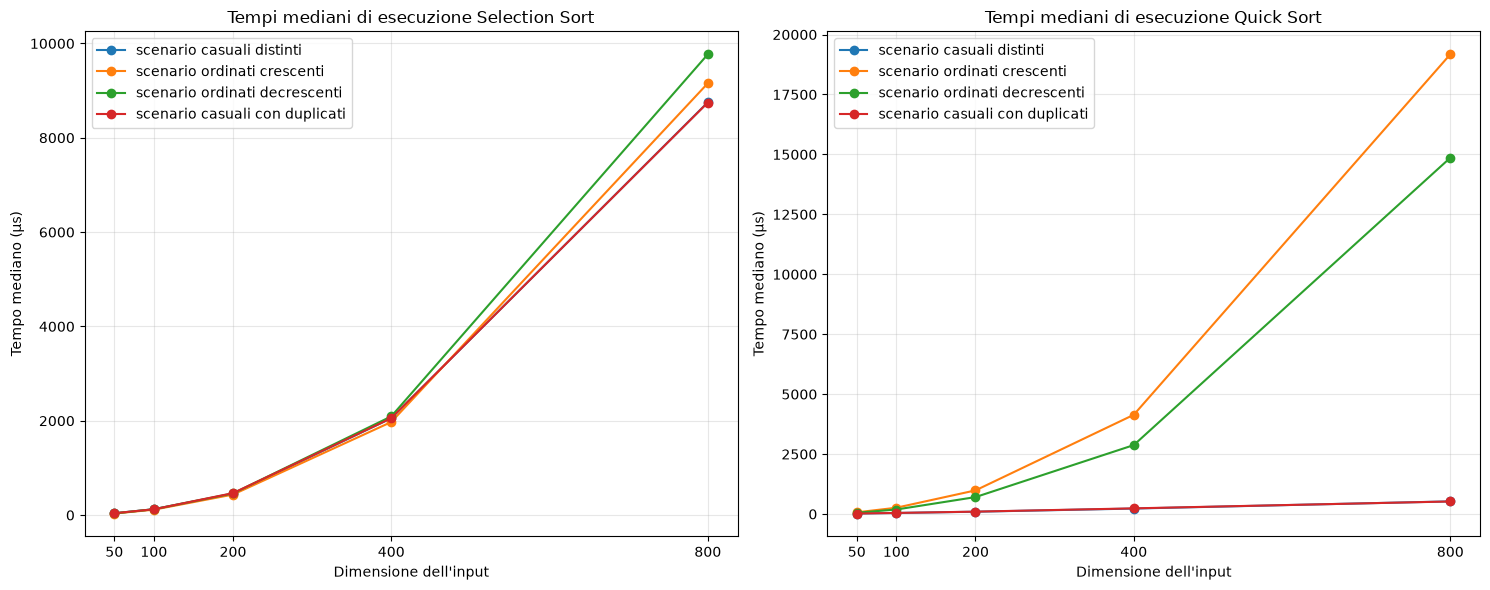

In [12]:
def disegna_tempi(ax, tempi_aggregati, nome_algoritmo):
    """
    Disegna su un asse i tempi mediani di un algoritmo
    per i quattro scenari sperimentali.

    Parametri:
    - ax: asse Matplotlib sul quale disegnare il grafico;
    - tempi_aggregati (dict): risultati nella forma tempi_aggregati[scenario][dimensione] = (mediana, IQR);
    - nome_algoritmo (str): nome dell'algoritmo utilizzato nel titolo.

    Returns:
    - None
    """

    for scenario, risultati in tempi_aggregati.items():

        # Estrae le mediane secondo l'ordine delle dimensioni definito nel protocollo.
        mediane_us = [risultati[dimensione][0] / 1000 for dimensione in DIMENSIONI]

        ax.plot(
            DIMENSIONI,
            mediane_us,
            marker="o",
            label=scenario
        )

    ax.set_title(f"Tempi mediani di esecuzione {nome_algoritmo}")
    ax.set_xlabel("Dimensione dell'input")
    ax.set_ylabel("Tempo mediano (µs)")
    ax.set_xticks(DIMENSIONI)
    ax.grid(True, alpha=0.3)
    ax.legend()


def crea_grafici_temporali(
    tempi_aggregati_selection,
    tempi_aggregati_quick
):
    """
    Crea due grafici affiancati contenenti i tempi mediani
    di Selection Sort e Quick Sort.

    Ogni grafico contiene una linea per ciascuno dei quattro
    scenari sperimentali.

    Parametri:
    - tempi_aggregati_selection (dict): risultati aggregati di Selection Sort;
    - tempi_aggregati_quick (dict): risultati aggregati di Quick Sort.

    Returns:
    - None
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    disegna_tempi(
        axes[0],
        tempi_aggregati_selection,
        "Selection Sort"
    )

    disegna_tempi(
        axes[1],
        tempi_aggregati_quick,
        "Quick Sort"
    )

    plt.tight_layout()
    plt.show()

# Visualizzazione grafici
crea_grafici_temporali(tempi_aggregati_selection, tempi_aggregati_quick)

# Analisi dei risultati

I risultati del benchmark temporale sono complessivamente coerenti con le aspettative teoriche.

### Selection Sort

Le curve relative a Selection Sort presentano un andamento molto simile nei quattro scenari considerati, confermando l'ipotesi teorica di come l'algoritmo è indipendente dall'input iniziale.  

Il comportamento è di fatti coerente con la struttura di Selection Sort: per ogni posizione viene comunque esaminata tutta la parte restante dell'array per individuarne il minimo. Il numero di confronti non dipende quindi dalla disposizione iniziale degli elementi e il costo temporale rimane dell'ordine di $\Theta(n^2)$.

All'aumentare della dimensione dell'input, i tempi crescono rapidamente e le quattro curve rimangono generalmente vicine tra loro. Le eventuali differenze temporali tra gli scenari sono relativamente piccole rispetto all'andamento complessivo e non indicano un vantaggio sistematico.

L'IQR riportato nelle tabelle permette inoltre di valutare la variabilità delle misurazioni tra le diverse ripetizioni.

### Quick Sort

Il comportamento di Quick Sort risulta invece fortemente influenzato dalle caratteristiche dell'input, a conferma delle ipotesi teoriche.

Negli scenari con valori disposti casualmente, sia distinti sia con duplicati, i tempi crescono molto più lentamente rispetto a Selection Sort. Le partizioni ottenute risultano generalmente meno sbilanciate e il comportamento osservato è coerente con il caso favorevole di ordine $\Theta(n \log n)$.

Negli scenari già ordinati in senso crescente o decrescente, invece, le prestazioni peggiorano nettamente. Con la scelta dell'ultimo elemento come pivot, questi input producono partizioni fortemente sbilanciate: a ogni chiamata ricorsiva uno dei due sottoarray contiene quasi tutti gli elementi rimanenti. Il comportamento si avvicina quindi al caso peggiore di ordine $\Theta(n^2)$.

Per le dimensioni maggiori, Quick Sort su input ordinati può risultare anche più lento di Selection Sort, mostrando come la migliore complessità media di Quick Sort non implichi prestazioni migliori per qualsiasi configurazione dell'input.

### Confronto complessivo

Il benchmark evidenzia quindi due caratteristiche differenti:

- **Selection Sort** presenta prestazioni prevedibili e poco dipendenti dall'ordinamento iniziale, ma mantiene un costo quadratico anche negli scenari favorevoli;
- **Quick Sort** è molto più efficiente sugli input casuali, ma la variante utilizzata è sensibile alla disposizione degli elementi e può degradare fino a un comportamento quadratico sugli input già ordinati.

La presenza di circa il 35% di duplicati, nelle prove effettuate, non determina un degrado paragonabile a quello osservato sugli input ordinati. Il comportamento dei duplicati verrà ulteriormente osservato attraverso il numero di confronti e di scambi.

## Benchmark di confronti e scambi

Il benchmark dei contatori di confronti e scambi viene eseguito dalla funzione `run_benchmark_contatori(rng)` utilizzando le versioni strumentate dei due algoritmi.

Per le medesime dimensioni e scenari, viene salvato il **numero di confronti** e il **numero di scambi** restituiti da `selection_sort_strumentato()` e `quick_sort_strumentato()`.

La struttura dell'esperimento rimane analoga a quella del benchmark temporale: per ogni ripetizione vengono generati nuovi input e i due algoritmi ricevono copie dello stesso array iniziale. Al contrario del benchmark temporale, il conteggio del numero dii confronti e di scambi non ha dipendenze dalle condizioni temporanee dell-ambiente di esecuzione, quindi i due algoritmi non sono alternati nell'esecuzione.

Per ogni combinazione tra scenario e dimensione vengono effettuate 30 ripetizioni. Al termine delle ripetizioni viene calcolata la **mediana** dei conteggi ottenuti.

Il significato delle ripetizioni è differente per i due algoritmi. In Selection Sort il numero di confronti e di scambi dipende solamente dalla dimensione dell'input e rimane quindi invariato tra scenari diversi della stessa dimensione. In Quick Sort, invece, i conteggi dipendono dalla posizione assunta dal pivot durante le successive partizioni e quindi anche dalla disposizione dei valori nell'input.

La funzione restituisce quattro dizionari aggregati:
- confronti di Selection Sort;
- scambi di Selection Sort;
- confronti di Quick Sort;
- scambi di Quick Sort.

Ogni dizionario è indicizzato prima per scenario e poi per dimensione e contiene come valore la mediana delle 30 ripetizioni.

In [13]:
# Generazione di un seed dedicato all'esperimento sui contatori.
seed_contatori, rng_contatori = generate_seed()


def aggrega_contatori(conteggi_grezzi, conteggi_aggregati, dimensione):
    """
    Calcola la mediana dei conteggi raccolti per ogni scenario
    e aggiorna il dizionario dei risultati aggregati

    Parametri:
    - conteggi_grezzi (dict): dizionario che associa ogni scenario alla lista dei conteggi ottenuti nelle diverse ripetizioni
    - conteggi_aggregati (dict): dizionario nel quale vengono memorizzati i valori aggregati
    - dimensione (int): dimensione degli input a cui si riferiscono i conteggi

    Returns:
    - dict: dizionario aggiornato nella forma conteggi_aggregati[scenario][dimensione] = mediana
    """

    for scenario, conteggi in conteggi_grezzi.items():
        mediana = statistics.median(conteggi)
        conteggi_aggregati[scenario][dimensione] = mediana

    return conteggi_aggregati


def run_benchmark_contatori(rng):
    """
    Esegue il benchmark del numero di confronti e di scambi
    effettuati da Selection Sort e Quick Sort.

    Per ogni dimensione prevista dal protocollo vengono effettuate
    RIPETIZIONI prove sui quattro scenari di input.

    A ogni prova i due algoritmi ricevono copie dello stesso input
    iniziale. Le versioni strumentate restituiscono direttamente
    il numero di confronti e di scambi effettuati.

    Parametri:
    - rng (random.Random): generatore pseudocasuale utilizzato per creare gli input

    Returns:
    - tuple[dict, dict, dict, dict]:
        - confronti aggregati di Selection Sort
        - scambi aggregati di Selection Sort
        - confronti aggregati di Quick Sort
        - scambi aggregati di Quick Sort

      Ogni dizionario ha struttura: risultati[scenario][dimensione] = mediana
    """

    scenari = (
        "scenario casuali distinti",
        "scenario ordinati crescenti",
        "scenario ordinati decrescenti",
        "scenario casuali con duplicati"
    )

    # Dizionari contenenti i risultati aggregati finali
    confronti_aggregati_selection = {
        scenario: {} for scenario in scenari
    }

    scambi_aggregati_selection = {
        scenario: {} for scenario in scenari
    }

    confronti_aggregati_quick = {
        scenario: {} for scenario in scenari
    }

    scambi_aggregati_quick = {
        scenario: {} for scenario in scenari
    }

    # Ciclo sulle dimensioni previste
    for dimensione in DIMENSIONI:

        # Liste temporanee relative alla dimensione corrente
        confronti_selection = {
            scenario: [] for scenario in scenari
        }

        scambi_selection = {
            scenario: [] for scenario in scenari
        }

        confronti_quick = {
            scenario: [] for scenario in scenari
        }

        scambi_quick = {
            scenario: [] for scenario in scenari
        }

        # Ripetizioni previste per la dimensione corrente
        for _ in range(RIPETIZIONI):

            # Genera i quattro scenari sperimentali
            input_generati = generate_input(dimensione, rng)
            dati_scenari = dict(zip(scenari, input_generati))

            for scenario, input_originale in dati_scenari.items():

                # Selection Sort riceve una copia dell'input iniziale
                dati_selection = input_originale.copy()

                c_confronti_selection, c_scambi_selection = (
                    selection_sort_strumentato(dati_selection)
                )

                confronti_selection[scenario].append(
                    c_confronti_selection
                )

                scambi_selection[scenario].append(
                    c_scambi_selection
                )

                # Quick Sort riceve una seconda copia dello stesso input
                dati_quick = input_originale.copy()

                c_confronti_quick, c_scambi_quick = (
                    quick_sort_strumentato(dati_quick)
                )

                confronti_quick[scenario].append(
                    c_confronti_quick
                )

                scambi_quick[scenario].append(
                    c_scambi_quick
                )

        # Aggregazione dei risultati della dimensione corrente
        confronti_aggregati_selection = aggrega_contatori(confronti_selection, confronti_aggregati_selection, dimensione)
        scambi_aggregati_selection = aggrega_contatori(scambi_selection, scambi_aggregati_selection, dimensione)
        confronti_aggregati_quick = aggrega_contatori(confronti_quick, confronti_aggregati_quick, dimensione)
        scambi_aggregati_quick = aggrega_contatori(scambi_quick, scambi_aggregati_quick, dimensione)

        # Per monitorare l'avanzamento del benchmark
        print(f"Benchmark contatori completato per n = {dimensione}")

    return (
        confronti_aggregati_selection,
        scambi_aggregati_selection,
        confronti_aggregati_quick,
        scambi_aggregati_quick
    )


# Esecuzione dell'esperimento sui contatori.
confronti_aggregati_selection, scambi_aggregati_selection, confronti_aggregati_quick, scambi_aggregati_quick = run_benchmark_contatori(rng_contatori)

Seed utilizzato per la generazione dei dati: 9436204623682237481
Benchmark contatori completato per n = 50
Benchmark contatori completato per n = 100
Benchmark contatori completato per n = 200
Benchmark contatori completato per n = 400
Benchmark contatori completato per n = 800


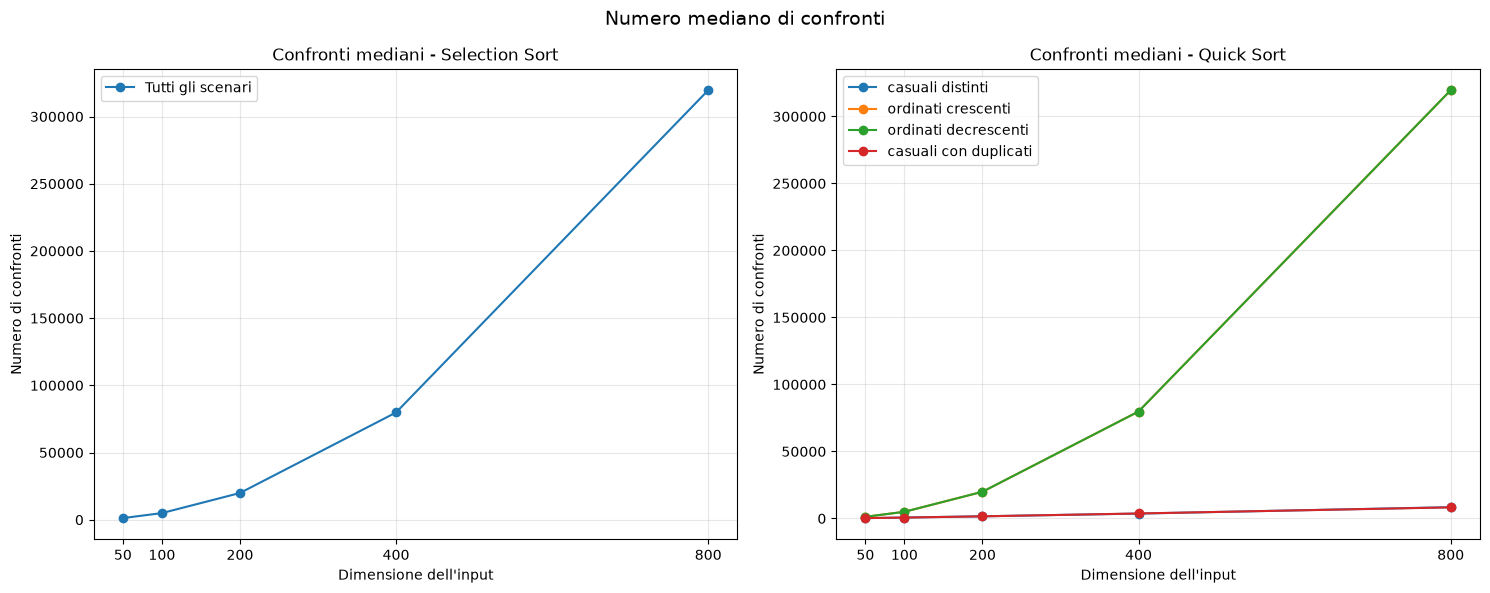

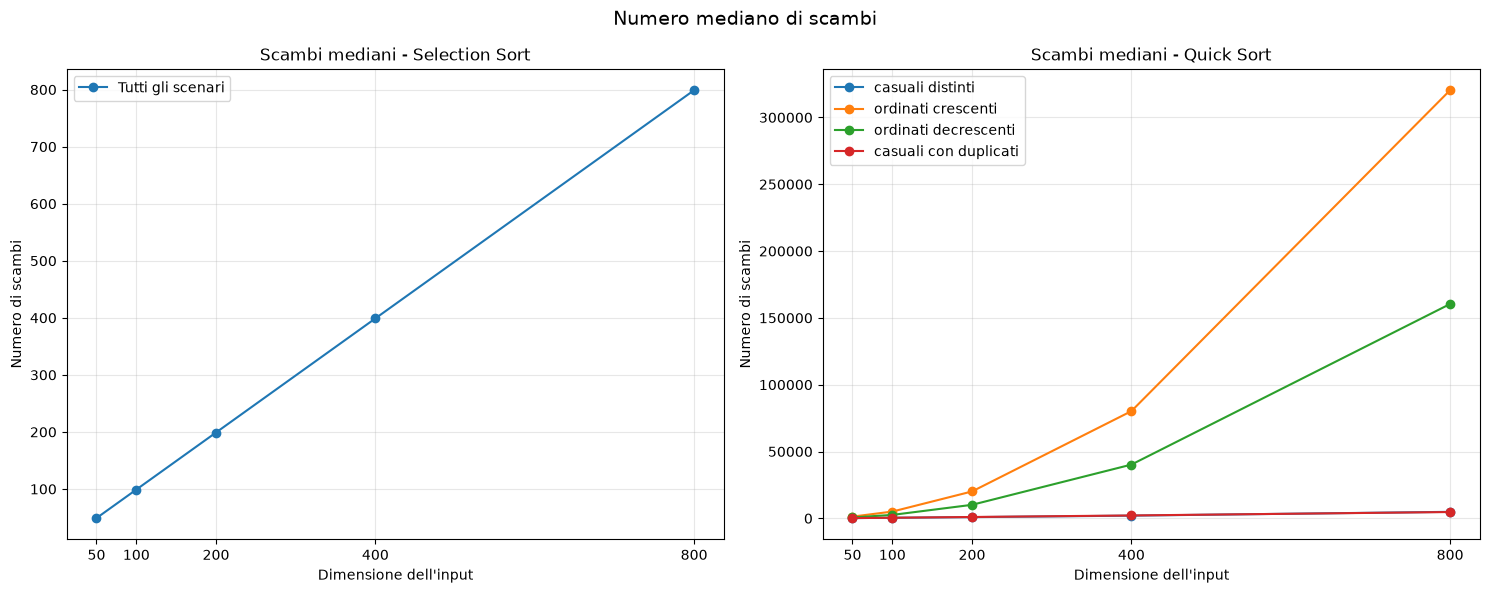

In [14]:
def crea_grafici_contatori(
    dati_selection,
    dati_quick,
    nome_metrica
):
    """
    Crea due grafici affiancati per confrontare l'andamento
    di una metrica di Selection Sort e Quick Sort.

    Per Selection Sort viene rappresentata una sola linea, poiché
    i conteggi sono identici nei quattro scenari.

    Per Quick Sort vengono rappresentate quattro linee, una per
    ciascuno scenario sperimentale.

    Parametri:
    - dati_selection (dict): risultati aggregati di Selection Sort nella forma dati_selection[scenario][dimensione] = mediana
    - dati_quick (dict): risultati aggregati di Quick Sort nella stessa forma
    - nome_metrica (str): nome della metrica rappresentata ("Confronti" oppure "Scambi")

    Returns:
    - None
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    # ---------------------------------------------------------
    # Selection Sort
    # ---------------------------------------------------------

    # I valori sono uguali nei quattro scenari, quindi è sufficiente
    # utilizzare uno scenario come rappresentante di tutti.
    primo_scenario = next(iter(dati_selection))

    valori_selection = [
        dati_selection[primo_scenario][dimensione]
        for dimensione in DIMENSIONI
    ]

    axes[0].plot(
        DIMENSIONI,
        valori_selection,
        marker="o",
        label="Tutti gli scenari"
    )

    axes[0].set_title(
        f"{nome_metrica} mediani - Selection Sort"
    )
    axes[0].set_xlabel("Dimensione dell'input")
    axes[0].set_ylabel(f"Numero di {nome_metrica.lower()}")
    axes[0].set_xticks(DIMENSIONI)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # ---------------------------------------------------------
    # Quick Sort
    # ---------------------------------------------------------

    for scenario, risultati in dati_quick.items():

        valori_quick = [
            risultati[dimensione]
            for dimensione in DIMENSIONI
        ]

        # Rimuove il prefisso "scenario " dalla legenda
        # per rendere le etichette più compatte.
        etichetta = scenario.removeprefix("scenario ")

        axes[1].plot(
            DIMENSIONI,
            valori_quick,
            marker="o",
            label=etichetta
        )

    axes[1].set_title(
        f"{nome_metrica} mediani - Quick Sort"
    )
    axes[1].set_xlabel("Dimensione dell'input")
    axes[1].set_ylabel(f"Numero di {nome_metrica.lower()}")
    axes[1].set_xticks(DIMENSIONI)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle(
        f"Numero mediano di {nome_metrica.lower()}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

# Visualizzazione grafici confronti
crea_grafici_contatori(confronti_aggregati_selection, confronti_aggregati_quick, "Confronti")

# Visualizzazione grafici scambi
crea_grafici_contatori(scambi_aggregati_selection, scambi_aggregati_quick, "Scambi")

## Analisi dei risultati

Come previsto dalle aspettative teoriche, per una stessa dimensione il numero di confronti e di scambi effettuati da **Selection Sort** rimane invariato nei quattro scenari.

Con le convenzioni adottate nell'implementazione si ottiene:

- $\text{\#confronti} = \frac{n(n-1)}{2}$, dovuto al fatto che l'algoritmo esamina tutta la parte dell'array non ancora ordinata.

- $\text{\#scambi} = n-1$, pari al numero di interazioni esterne, poiché quando ne termina una viene eseguito uno scambio.

Selection Sort presenta quindi un comportamento indipendente dalla disposizione iniziale degli elementi per entrambe le metriche considerate.

Il comportamento di **Quick Sort** è invece fortemente influenzato dalla struttura dell'input.

Negli scenari con valori distinti in ordine casuale e con duplicati, il numero di confronti cresce molto più lentamente rispetto ai casi ordinati. Le partizioni risultano generalmente meno sbilanciate e i conteggi osservati sono coerenti con il comportamento atteso di Quick Sort su input non sfavorevoli.

Negli input ordinati in senso crescente o decrescente, invece, la scelta dell'ultimo elemento come pivot produce partizioni sbilanciate, quindi ad ogni livello della ricrsione viene escluso un solo elemento, facendo cresce i confronti effettuati:

$\frac{n(n-1)}{2}$

che coincide con il numero di confronti effettuato da Selection Sort.

Anche il numero di scambi di Quick Sort dipende fortemente dall'input. Negli scenari casuali il numero di scambi rimane molto inferiore rispetto ai casi ordinati, ma risulta comunque superiore agli `n-1` scambi effettuati da Selection Sort.

La differenza tra input crescente e decrescente è particolarmente evidente. Nel caso crescente, ogni elemento esaminato risulta minore o uguale al pivot e viene quindi eseguita un'operazione di scambio a ogni confronto, comprendendo gli auto-scambi previsti dalla convenzione adottata. Nel caso decrescente le partizioni rimangono completamente sbilanciate, ma il numero di scambi risulta inferiore rispetto al caso crescente.

Nel complesso, i conteggi sperimentali risultano coerenti con il comportamento atteso dei due algoritmi e aiutano a spiegare gli andamenti osservati nel benchmark temporale.


## Confronto complessivo con le aspettative teoriche

I risultati ottenuti confermano le principali differenze teoriche tra **Selection Sort** e **Quick Sort**.

Selection Sort presenta un comportamento molto regolare. La disposizione iniziale degli elementi non modifica né il numero di confronti né il numero di scambi e anche i tempi di esecuzione mostrano andamenti simili nei quattro scenari. L'algoritmo effettua sempre un numero quadratico di confronti e mantiene quindi una complessità temporale di $\Theta(n^2)$. Il suo principale vantaggio, tra le metriche considerate, è il numero ridotto e prevedibile di scambi, pari a `n-1` con la convenzione utilizzata.

Quick Sort mostra invece prestazioni fortemente dipendenti dall'input. Con dati disposti casualmente le partizioni risultano generalmente più equilibrate e l'algoritmo richiede molti meno confronti rispetto a Selection Sort. Questo comportamento si riflette direttamente nei tempi misurati, nei quali Quick Sort risulta nettamente più veloce per le dimensioni maggiori.

La situazione cambia negli input già ordinati. Utilizzando sempre l'ultimo elemento come pivot, le partizioni diventano completamente sbilanciate e Quick Sort raggiunge il comportamento quadratico $\Theta(n^2)$. In questi scenari il numero di confronti coincide con quello di Selection Sort e, per le dimensioni maggiori, anche il vantaggio temporale di Quick Sort scompare, fino a poter risultare più lento.

Il numero di scambi mette inoltre in evidenza di come il Selection Sort esegue pochi scambi indipendentemente dall'input, mentre Quick Sort può eseguirne un numero molto maggiore, soprattutto negli input ordinati.

Il confronto sperimentale evidenzia quindi che non esiste un algoritmo migliore in modo assoluto rispetto a tutte le caratteristiche considerate. **Selection Sort** è semplice, prevedibile e richiede pochi scambi, ma mantiene un costo quadratico anche quando l'input è favorevole. **Quick Sort** offre prestazioni nettamente migliori sugli input casuali, ma la variante utilizzata è sensibile alla scelta del pivot e alla disposizione iniziale degli elementi, potendo degradare fino al caso quadratico sugli input sfavorevoli.

Gli esperimenti risultano quindi coerenti con le aspettative teoriche e mostrano concretamente vantaggi e svantaggi dei due algoritmi al variare dell'input.
